## MeanDiff CAV 

In [8]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import itertools
import seaborn as sns

import torch
import clip
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from data_loading import load_sun_data
import torchvision.models as models
from torchvision import transforms as trn
import torch.nn as nn
from tqdm import tqdm
from dataloaders import create_sun_dataloader
from cav_utils import (
    calculate_centroid_cav,
    calculate_hcep_cav,
    calculate_filtered_cav,
    get_cosine_similarity,
    get_dot_product_similarity,
)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Używane urządzenie: {DEVICE}")


Używane urządzenie: cuda


#### Wczytanie danych i ekstrakcja cech

In [9]:
df_sun, attributes_list, attr_cols = load_sun_data(base_path='data/SUN/SUNAttributeDB', threshold=0.5)

print(f'Wczytano obrazy: {len(df_sun)}')
print(f'Liczba atrybutów: {len(attr_cols)}')

df_sun.head(3)

Wczytano obrazy: 14340
Liczba atrybutów: 102


,image_id,file_path,class_id,sailing/ boating,driving,biking,transporting things or people,sunbathing,vacationing/ touring,hiking,...,far-away horizon,no horizon,rugged scene,mostly vertical components,mostly horizontal components,symmetrical,cluttered space,scary,soothing,stressful
0,1,a/abbey/sun_aakbdcgfpksytcwj.jpg,a,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
1,2,a/abbey/sun_aaoktempcmudsvna.jpg,a,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3,a/abbey/sun_abegcweqnetpdlrh.jpg,a,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [10]:
model_file = 'models/resnet18_places365.pth'
conv_model = models.resnet18(num_classes=365)
checkpoint = torch.load(model_file, map_location=lambda storage, loc: storage)
state_dict = {str.replace(k, 'module.', ''): v for k, v in checkpoint['state_dict'].items()}
conv_model.load_state_dict(state_dict)
conv_model.fc = nn.Identity() 
conv_model = conv_model.to(DEVICE).eval()

centre_crop = trn.Compose([
    trn.Resize((256, 256)),
    trn.CenterCrop(224),
    trn.ToTensor(),
    trn.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

clip_model, clip_preprocess = clip.load('ViT-B/32', device=DEVICE)
clip_model.eval()
print(f'Modele załadowane. Wymiar embeddingu CLIP: {clip_model.visual.output_dim}')


Modele załadowane. Wymiar embeddingu CLIP: 512


In [11]:
dataloader_resnet = create_sun_dataloader(
    df=df_sun, img_dir='data/SUN/images/', transform=centre_crop,
    attr_cols=attr_cols, batch_size=32, num_workers=4
)

dataloader_clip = create_sun_dataloader(
    df=df_sun, img_dir='data/SUN/images/', transform=clip_preprocess,
    attr_cols=attr_cols, batch_size=64, num_workers=4)

In [12]:
features_conv = []
with torch.no_grad():
    for batch_imgs, _, _ in tqdm(dataloader_resnet, desc='ResNet18 features'):
        batch_imgs = batch_imgs.to(DEVICE)
        feats = conv_model(batch_imgs)
        features_conv.append(feats.cpu().numpy())
X_conv = np.concatenate(features_conv, axis=0)

ResNet18 features: 100%|██████████| 449/449 [00:56<00:00,  7.88it/s]


In [13]:
features_clip = []
with torch.no_grad():
    for batch_imgs, _, _ in tqdm(dataloader_clip, desc='CLIP features'):
        batch_imgs = batch_imgs.to(DEVICE)
        feats = clip_model.encode_image(batch_imgs).float()
        feats = feats / feats.norm(dim=1, keepdim=True)
        features_clip.append(feats.cpu().numpy())
X_clip = np.concatenate(features_clip, axis=0)


CLIP features: 100%|██████████| 225/225 [02:36<00:00,  1.44it/s]


#### Wyznaczenie CAV dla relacji empirycznych

In [14]:
empirical_pairs = [
    ('research', 'enclosed area'),
    ('camping', 'open area'),
    ('medical activity', 'enclosed area'),
    ('gaming', 'enclosed area'),
    ('sand', 'natural light'),
    ('carpet', 'enclosed area')
]

In [15]:
results_empirical = []

In [16]:
for concept_a, concept_b in empirical_pairs:
    idx_a = df_sun.index[df_sun[concept_a] == 1.0].tolist()
    idx_not_a = df_sun.index[df_sun[concept_a] == 0.0].tolist()
    idx_b = df_sun.index[df_sun[concept_b] == 1.0].tolist()
    idx_not_b = df_sun.index[df_sun[concept_b] == 0.0].tolist()

    cav_res_a = calculate_centroid_cav(X_conv, idx_a, idx_not_a)
    cav_res_b = calculate_centroid_cav(X_conv, idx_b, idx_not_b)
    sim_resnet = get_cosine_similarity(cav_res_a, cav_res_b)

    cav_clip_a = calculate_centroid_cav(X_clip, idx_a, idx_not_a)
    cav_clip_b = calculate_centroid_cav(X_clip, idx_b, idx_not_b)
    sim_clip = get_cosine_similarity(cav_clip_a, cav_clip_b)

    results_empirical.append({
        'Zjawisko (A)': concept_a,
        'Atrybut (B)': concept_b,
        'Próbki (A)': len(idx_a),
        'Próbki (B)': len(idx_b),
        'ResNet18_CosSim': round(sim_resnet, 4),
        'CLIP_Vision_CosSim': round(sim_clip, 4)
    })

df_results_emp = pd.DataFrame(results_empirical)
df_results_emp


,Zjawisko (A),Atrybut (B),Próbki (A),Próbki (B),ResNet18_CosSim,CLIP_Vision_CosSim
0,research,enclosed area,207,4947,0.7293,0.6130
1,camping,open area,871,5541,0.7919,0.8143
2,medical activity,enclosed area,118,4947,0.6150,0.4607
3,gaming,enclosed area,108,4947,0.6190,0.5380
4,sand,natural light,351,6709,0.6086,0.6044
5,carpet,enclosed area,324,4947,0.8100,0.7916


#### Wyznaczenie CAV dla relacji semantycznych

In [17]:
semantic_pairs = [
    ('ocean', 'open area'),
    ('conducting business', 'working'),
    ('pavement', 'asphalt'),
    ('climbing', 'rock/stone'), 
    ('rusty', 'aged/ worn'),  
    ('ice', 'cold')
]

In [18]:
results_semantic = []

In [19]:
for concept_a, concept_b in semantic_pairs:
    idx_a = df_sun.index[df_sun[concept_a] == 1.0].tolist()
    idx_not_a = df_sun.index[df_sun[concept_a] == 0.0].tolist()
    idx_b = df_sun.index[df_sun[concept_b] == 1.0].tolist()
    idx_not_b = df_sun.index[df_sun[concept_b] == 0.0].tolist()

    cav_res_a = calculate_centroid_cav(X_conv, idx_a, idx_not_a)
    cav_res_b = calculate_centroid_cav(X_conv, idx_b, idx_not_b)
    sim_resnet = get_cosine_similarity(cav_res_a, cav_res_b)

    cav_clip_a = calculate_centroid_cav(X_clip, idx_a, idx_not_a)
    cav_clip_b = calculate_centroid_cav(X_clip, idx_b, idx_not_b)
    sim_clip = get_cosine_similarity(cav_clip_a, cav_clip_b)

    results_semantic.append({
        'Zjawisko (A)': concept_a,
        'Atrybut (B)': concept_b,
        'Próbki (A)': len(idx_a),
        'Próbki (B)': len(idx_b),
        'ResNet18_CosSim': round(sim_resnet, 4),
        'CLIP_Vision_CosSim': round(sim_clip, 4)
    })

df_results_sem = pd.DataFrame(results_semantic)
df_results_sem

,Zjawisko (A),Atrybut (B),Próbki (A),Próbki (B),ResNet18_CosSim,CLIP_Vision_CosSim
0,ocean,open area,413,5541,0.4826,0.5312
1,conducting business,working,263,1032,0.8417,0.7437
2,pavement,asphalt,632,635,0.8611,0.8237
3,climbing,rock/stone,638,594,0.9046,0.8940
4,rusty,aged/ worn,280,631,0.5616,0.4659
5,ice,cold,158,388,0.9584,0.9513


#### Wyznaczenie CAV dla CLIP - zero-shot

In [20]:
def get_text_cav_clip(concept_word, base_prompt="a photo of a place"):
    with torch.no_grad():
        prompt_concept = f"{base_prompt} that has {concept_word}"
        tokens_concept = clip.tokenize([prompt_concept]).to(DEVICE)
        tokens_bg = clip.tokenize([base_prompt]).to(DEVICE)
        emb_concept = clip_model.encode_text(tokens_concept).float()
        emb_bg = clip_model.encode_text(tokens_bg).float()
        cav = (emb_concept - emb_bg).cpu().numpy().squeeze()
        norm = np.linalg.norm(cav)
        if norm > 0:
            cav = cav / norm
            
        return cav

In [21]:
results_empirical = []
print("Obliczanie CAV tekstowych (CLIP Zero-Shot)...\n")

for concept_a, concept_b in empirical_pairs:
    cav_text_a = get_text_cav_clip(concept_a)
    cav_text_b = get_text_cav_clip(concept_b)
    sim_text = get_cosine_similarity(cav_text_a, cav_text_b)
    results_empirical.append({
        'Pojęcie (A)': concept_a,
        'Powiązane pojęcie (B)': concept_b,
        'CLIP_Text_CosSim': round(sim_text, 4)
    })

df_results_emp = pd.DataFrame(results_empirical)
df_results_emp.sort_values(by='CLIP_Text_CosSim', ascending=False).reset_index(drop=True)

Obliczanie CAV tekstowych (CLIP Zero-Shot)...



,Pojęcie (A),Powiązane pojęcie (B),CLIP_Text_CosSim
0,camping,open area,0.3474
1,research,enclosed area,0.3374
2,medical activity,enclosed area,0.3317
3,gaming,enclosed area,0.3234
4,sand,natural light,0.2901
5,carpet,enclosed area,0.2540


In [22]:
results_semantic = []
print("Obliczanie CAV tekstowych (CLIP Zero-Shot)...\n")

for concept_a, concept_b in semantic_pairs:
    cav_text_a = get_text_cav_clip(concept_a)
    cav_text_b = get_text_cav_clip(concept_b)
    sim_text = get_cosine_similarity(cav_text_a, cav_text_b)
    results_semantic.append({
        'Pojęcie (A)': concept_a,
        'Powiązane pojęcie (B)': concept_b,
        'CLIP_Text_CosSim': round(sim_text, 4)
    })

df_results_sem = pd.DataFrame(results_semantic)
df_results_sem.sort_values(by='CLIP_Text_CosSim', ascending=False).reset_index(drop=True)

Obliczanie CAV tekstowych (CLIP Zero-Shot)...



,Pojęcie (A),Powiązane pojęcie (B),CLIP_Text_CosSim
0,pavement,asphalt,0.7326
1,ice,cold,0.6769
2,conducting business,working,0.6485
3,climbing,rock/stone,0.5681
4,rusty,aged/ worn,0.5346
5,ocean,open area,0.2411


#### Carpet - enclosed area jest mocno podbite - najpewniej w zbiorze danych są same dywany wewnątrz
#### Dla empirycznych relacji podobieństwa znacznie niższe niż dla semantycznych dla zero-shot CLIP

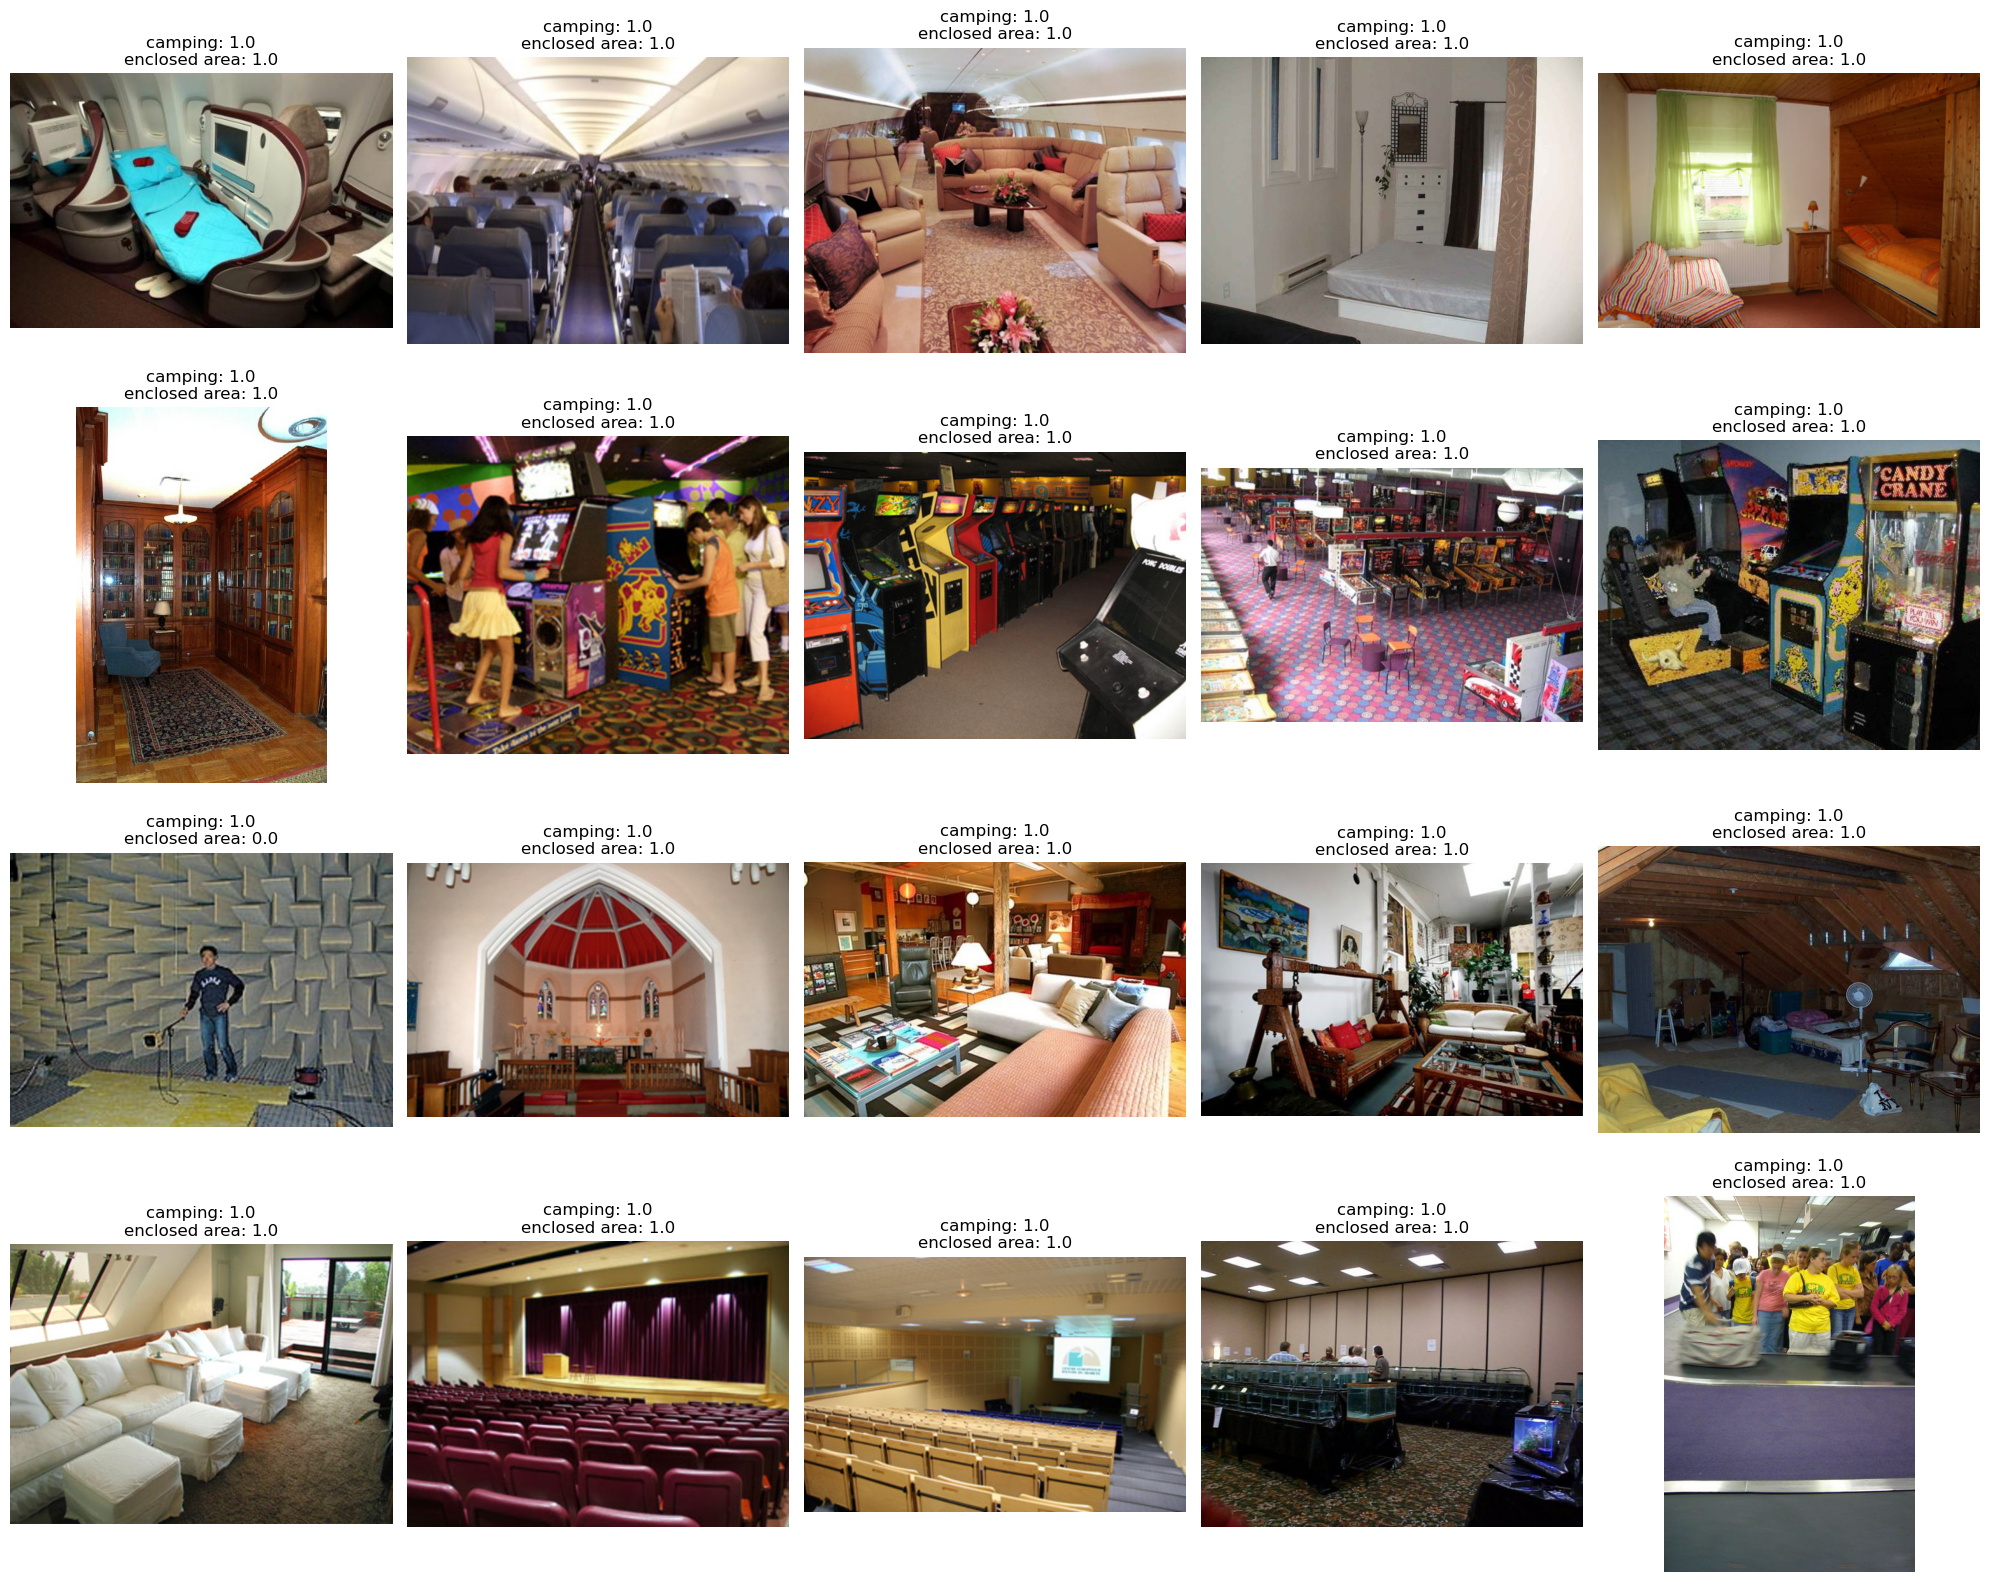

In [23]:
camping_samples = df_sun[df_sun['carpet'] == 1.0].head(20)

fig, axes = plt.subplots(4, 5, figsize=(20, 16))

for ax, (_, row) in zip(axes.flatten(), camping_samples.iterrows()):
    img_path = os.path.join('data/SUN/images/', row['file_path'])
    
    try:
        img = Image.open(img_path)
        ax.imshow(img)
        rock_stone_val = row['enclosed area']
        ax.set_title(f"camping: 1.0\nenclosed area: {rock_stone_val}")
    except Exception as e:
        ax.set_title("Brak pliku")
        
    ax.axis('off')

plt.tight_layout()
plt.show()

### Ewaluacja CAV - podział na trening i test

1) CLIP

In [24]:
indices = np.arange(len(df_sun))
train_idx, test_idx = train_test_split(indices, test_size=0.2, random_state=42)

X_train = X_clip[train_idx]
X_test  = X_clip[test_idx]

df_train = df_sun.iloc[train_idx].reset_index(drop=True)
df_test  = df_sun.iloc[test_idx].reset_index(drop=True)

print(f"Zbiór treningowy: {X_train.shape[0]} próbek")
print(f"Zbiór testowy: {X_test.shape[0]} próbek")

Zbiór treningowy: 11472 próbek
Zbiór testowy: 2868 próbek


In [25]:
all_pairs = empirical_pairs + semantic_pairs
child_to_parent = {a: b for a, b in all_pairs}
concepts_to_test = set()
for a, b in all_pairs:
    concepts_to_test.add(a)
    concepts_to_test.add(b)

valid_concepts = []
auc_results = {}
auc_results_hard = {}

for concept in concepts_to_test:

    idx_pos = df_train.index[df_train[concept] == 1.0].tolist()
    idx_neg = df_train.index[df_train[concept] == 0.0].tolist()
        
    cav = calculate_centroid_cav(X_train, idx_pos, idx_neg)

    y_test  = df_test[concept].values
    scores = cosine_similarity(X_test, cav.reshape(1, -1)).flatten()
    
    auc = roc_auc_score(y_test, scores)
    auc_results[concept] = auc

    if auc >= 0.70: 
        valid_concepts.append(concept)
    
    if concept in child_to_parent:
        parent_concept = child_to_parent[concept]

        hard_mask = (df_test[parent_concept] == 1.0).values
        
        y_test_hard = df_test[concept].values[hard_mask]
        X_test_hard = X_test[hard_mask]

        if len(np.unique(y_test_hard)) > 1:
            scores_hard = cosine_similarity(X_test_hard, cav.reshape(1, -1)).flatten()
            auc_hard = roc_auc_score(y_test_hard, scores_hard)
            auc_results_hard[concept] = auc_hard
        else:
            auc_results_hard[concept] = None

sorted_results = sorted(auc_results.items(), key=lambda x: x[1], reverse=True)

print("\n" + "="*125)
print(" PODSUMOWANIE WYNIKÓW: STANDARD VS HARD NEGATIVES (TEST SPLĄTANIA)")
print("="*125)
print(f"{'POJĘCIE':<22} | {'HIERARCHIA (ROLA)':<35} | {'STD AUC':<7} | {'HARD AUC':<8} | {'SPADEK':<7} | {'WNIOSEK / STATUS'}")
print("-" * 125)

for concept, auc_std in sorted_results:
    if concept in child_to_parent:
        parent_concept = child_to_parent[concept]
        relacja = f"Podrzędne (wewnątrz: {parent_concept})"

        if concept in auc_results_hard and auc_results_hard[concept] is not None:
            auc_hard = auc_results_hard[concept]
            spadek = auc_std - auc_hard

            if auc_std < 0.70:
                status = "❌ SŁABY WEKTOR BAZOWY"
            elif spadek < 0.1:
                status = "✅ ODPORNY (Dobra separacja)"
            elif spadek >= 0.1:
                status = "🚨 Problem z rozróżnieniem w hierarchii"
                
            print(f"{concept:<22} | {relacja:<35} | {auc_std:<7.3f} | {auc_hard:<8.3f} | {spadek:<7.3f} | {status}")
        else:
            print(f"{concept:<22} | {relacja:<35} | {auc_std:<7.3f} | {'Brak':<8} | {'---':<7} | ⚠️ Zbyt mała próba twardych negatywów")
            
    else:
        podr_pojecia = [k for k, v in child_to_parent.items() if v == concept]
        if podr_pojecia:
            relacja = f"Nadrzędne (Tło dla {len(podr_pojecia)} pojęć)"
        else:
            relacja = "Brak relacji"
            
        status = "--- (Baza / Pojęcie referencyjne)"
        print(f"{concept:<22} | {relacja:<35} | {auc_std:<7.3f} | {'---':<8} | {'---':<7} | {status}")

print("="*125)


 PODSUMOWANIE WYNIKÓW: STANDARD VS HARD NEGATIVES (TEST SPLĄTANIA)
POJĘCIE                | HIERARCHIA (ROLA)                   | STD AUC | HARD AUC | SPADEK  | WNIOSEK / STATUS
-----------------------------------------------------------------------------------------------------------------------------
medical activity       | Podrzędne (wewnątrz: enclosed area) | 0.990   | 0.974    | 0.016   | ✅ ODPORNY (Dobra separacja)
ice                    | Podrzędne (wewnątrz: cold)          | 0.984   | 0.857    | 0.127   | 🚨 Problem z rozróżnieniem w hierarchii
ocean                  | Podrzędne (wewnątrz: open area)     | 0.979   | 0.960    | 0.019   | ✅ ODPORNY (Dobra separacja)
gaming                 | Podrzędne (wewnątrz: enclosed area) | 0.976   | 0.951    | 0.026   | ✅ ODPORNY (Dobra separacja)
research               | Podrzędne (wewnątrz: enclosed area) | 0.967   | 0.919    | 0.048   | ✅ ODPORNY (Dobra separacja)
enclosed area          | Nadrzędne (Tło dla 4 pojęć)         | 0.957   | -

2) ResNet

In [26]:
X_train = X_conv[train_idx]
X_test  = X_conv[test_idx]

df_train = df_sun.iloc[train_idx].reset_index(drop=True)
df_test  = df_sun.iloc[test_idx].reset_index(drop=True)

In [27]:
valid_concepts = []
auc_results = {}
auc_results_hard = {}

for concept in concepts_to_test:

    idx_pos = df_train.index[df_train[concept] == 1.0].tolist()
    idx_neg = df_train.index[df_train[concept] == 0.0].tolist()
        
    cav = calculate_centroid_cav(X_train, idx_pos, idx_neg)

    y_test  = df_test[concept].values
    scores = cosine_similarity(X_test, cav.reshape(1, -1)).flatten()
    
    auc = roc_auc_score(y_test, scores)
    auc_results[concept] = auc

    if auc >= 0.70: 
        valid_concepts.append(concept)
    
    if concept in child_to_parent:
        parent_concept = child_to_parent[concept]

        hard_mask = (df_test[parent_concept] == 1.0).values
        
        y_test_hard = df_test[concept].values[hard_mask]
        X_test_hard = X_test[hard_mask]

        if len(np.unique(y_test_hard)) > 1:
            scores_hard = cosine_similarity(X_test_hard, cav.reshape(1, -1)).flatten()
            auc_hard = roc_auc_score(y_test_hard, scores_hard)
            auc_results_hard[concept] = auc_hard
        else:
            auc_results_hard[concept] = None

sorted_results = sorted(auc_results.items(), key=lambda x: x[1], reverse=True)

print("\n" + "="*125)
print(" PODSUMOWANIE WYNIKÓW: STANDARD VS HARD NEGATIVES (TEST SPLĄTANIA)")
print("="*125)
print(f"{'POJĘCIE':<22} | {'HIERARCHIA (ROLA)':<35} | {'STD AUC':<7} | {'HARD AUC':<8} | {'SPADEK':<7} | {'WNIOSEK / STATUS'}")
print("-" * 125)

for concept, auc_std in sorted_results:
    if concept in child_to_parent:
        parent_concept = child_to_parent[concept]
        relacja = f"Podrzędne (wewnątrz: {parent_concept})"

        if concept in auc_results_hard and auc_results_hard[concept] is not None:
            auc_hard = auc_results_hard[concept]
            spadek = auc_std - auc_hard

            if auc_std < 0.70:
                status = "❌ SŁABY WEKTOR BAZOWY"
            elif spadek < 0.1:
                status = "✅ ODPORNY (Dobra separacja)"
            elif spadek >= 0.1:
                status = "🚨 Problem z rozróżnieniem w hierarchii"
                
            print(f"{concept:<22} | {relacja:<35} | {auc_std:<7.3f} | {auc_hard:<8.3f} | {spadek:<7.3f} | {status}")
        else:
            print(f"{concept:<22} | {relacja:<35} | {auc_std:<7.3f} | {'Brak':<8} | {'---':<7} | ⚠️ Zbyt mała próba twardych negatywów")
            
    else:
        podr_pojecia = [k for k, v in child_to_parent.items() if v == concept]
        if podr_pojecia:
            relacja = f"Nadrzędne (Tło dla {len(podr_pojecia)} pojęć)"
        else:
            relacja = "Brak relacji"
            
        status = "--- (Baza / Pojęcie referencyjne)"
        print(f"{concept:<22} | {relacja:<35} | {auc_std:<7.3f} | {'---':<8} | {'---':<7} | {status}")

print("="*125)


 PODSUMOWANIE WYNIKÓW: STANDARD VS HARD NEGATIVES (TEST SPLĄTANIA)
POJĘCIE                | HIERARCHIA (ROLA)                   | STD AUC | HARD AUC | SPADEK  | WNIOSEK / STATUS
-----------------------------------------------------------------------------------------------------------------------------
ocean                  | Podrzędne (wewnątrz: open area)     | 0.982   | 0.967    | 0.015   | ✅ ODPORNY (Dobra separacja)
ice                    | Podrzędne (wewnątrz: cold)          | 0.982   | 0.849    | 0.133   | 🚨 Problem z rozróżnieniem w hierarchii
medical activity       | Podrzędne (wewnątrz: enclosed area) | 0.980   | 0.946    | 0.035   | ✅ ODPORNY (Dobra separacja)
enclosed area          | Nadrzędne (Tło dla 4 pojęć)         | 0.967   | ---      | ---     | --- (Baza / Pojęcie referencyjne)
asphalt                | Nadrzędne (Tło dla 1 pojęć)         | 0.967   | ---      | ---     | --- (Baza / Pojęcie referencyjne)
gaming                 | Podrzędne (wewnątrz: enclosed area) |

##### Wyniki są całkiem podobne dla obu modeli, są pary pojęć dla których hierarchia działa dobrze, ale są też pary gdzie działa źle

### Analiza jak próg pokrywania się konceptów wpływa na podobieństwo cosinusowe (można zrobić poziom ortogonalności analogicznie dla HCEP)

In [28]:
def find_soft_hierarchies(y_concepts, min_p=0.4, max_p=0.7, min_samples=50):
    """
    y_concepts: tablica numpy o wymiarach (liczba_próbek, liczba_koncepcji)
                zawierająca 0 i 1 (np. występowanie atrybutów).
    """
    num_concepts = y_concepts.shape[1]
    candidates = []

    for a in range(num_concepts):
        idx_a = y_concepts[:, a] == 1
        count_a = np.sum(idx_a)

        if count_a < min_samples:
            continue

        prob_b_given_a = y_concepts[idx_a].mean(axis=0)
        
        for b in range(num_concepts):
            if a == b: continue
            
            p = prob_b_given_a[b]
            if min_p <= p <= max_p:
                candidates.append({
                    'concept_A': a,
                    'concept_B': b,
                    'P(B|A)': p,
                    'samples_A': count_a
                })

    return sorted(candidates, key=lambda x: x['P(B|A)'], reverse=True)

In [29]:
def generate_ablation_subsets(activations, y_concepts, a_idx, b_idx, target_probs):
    """
    Zwraca słownik z maskami (indeksami), które filtrują zbiór tak, 
    aby osiągnąć docelowe prawdopodobieństwa P(B|A).
    """
    idx_a_and_b = np.where((y_concepts[:, a_idx] == 1) & (y_concepts[:, b_idx] == 1))[0]
    idx_a_not_b = np.where((y_concepts[:, a_idx] == 1) & (y_concepts[:, b_idx] == 0))[0]
    
    count_ab = len(idx_a_and_b)
    
    subsets = {}
    for p_target in target_probs:
        # Wzór na docelową liczbę próbek (A bez B):
        # P(B|A) = |A_and_B| / (|A_and_B| + |A_not_B_kept|)
        # Przekształcając: |A_not_B_kept| = |A_and_B| * (1 - P(B|A)) / P(B|A)
        
        if p_target == 1.0:
            keep_a_not_b = 0
        else:
            keep_a_not_b = int(count_ab * (1 - p_target) / p_target)

        keep_a_not_b = min(keep_a_not_b, len(idx_a_not_b))

        if keep_a_not_b > 0:
            kept_not_b_indices = np.random.choice(idx_a_not_b, keep_a_not_b, replace=False)
            current_a_indices = np.concatenate([idx_a_and_b, kept_not_b_indices])
        else:
            current_a_indices = idx_a_and_b
            
        subsets[p_target] = current_a_indices
        
    return subsets

In [30]:
y_labels = df_sun[attr_cols].values
soft_pairs = find_soft_hierarchies(y_labels, min_p=0.45, max_p=0.5, min_samples=100)

print("Znalezione miękkie hierarchie (top 20):")
print("-" * 75)
for pair in soft_pairs[:20]:
    nazwa_A = attr_cols[pair['concept_A']]
    nazwa_B = attr_cols[pair['concept_B']]
    print(f"A: {nazwa_A:<20} -> B: {nazwa_B:<20} | P(B|A) = {pair['P(B|A)']:.3f} | Próbki A = {pair['samples_A']}")

Znalezione miękkie hierarchie (top 20):
---------------------------------------------------------------------------
A: gaming               -> B: man-made             | P(B|A) = 0.500 | Próbki A = 108
A: medical activity     -> B: sterile              | P(B|A) = 0.500 | Próbki A = 118
A: conducting business  -> B: man-made             | P(B|A) = 0.498 | Próbki A = 263
A: bathing              -> B: natural light        | P(B|A) = 0.497 | Próbki A = 169
A: cloth                -> B: man-made             | P(B|A) = 0.497 | Próbki A = 1361
A: flowers              -> B: shrubbery            | P(B|A) = 0.495 | Próbki A = 214
A: sailing/ boating     -> B: swimming             | P(B|A) = 0.494 | Próbki A = 672
A: rock/stone           -> B: rugged scene         | P(B|A) = 0.493 | Próbki A = 594
A: warm                 -> B: man-made             | P(B|A) = 0.493 | Próbki A = 876
A: running water        -> B: no horizon           | P(B|A) = 0.491 | Próbki A = 277
A: man-made             -> B: no 

In [31]:
nazwa_A = 'sailing/ boating'
nazwa_B = 'ocean'

a_idx = attr_cols.index(nazwa_A)  
b_idx = attr_cols.index(nazwa_B) 

target_probs = np.arange(0.50, 1.01, 0.01)
subsets_a = generate_ablation_subsets(X_conv, y_labels, a_idx, b_idx, target_probs)

Ewaluacja przejścia dla ResNet18 (sailing/ boating -> ocean):
Docelowe P(B|A): 0.50 | MD Sim:  0.9642 | HCEP Sim:  0.0000 | Filtered Sim:  0.2681
Docelowe P(B|A): 0.55 | MD Sim:  0.9701 | HCEP Sim: -0.0000 | Filtered Sim:  0.2681
Docelowe P(B|A): 0.60 | MD Sim:  0.9784 | HCEP Sim: -0.0000 | Filtered Sim:  0.2681
Docelowe P(B|A): 0.65 | MD Sim:  0.9808 | HCEP Sim: -0.0000 | Filtered Sim:  0.2681
Docelowe P(B|A): 0.70 | MD Sim:  0.9862 | HCEP Sim:  0.0000 | Filtered Sim:  0.2681
Docelowe P(B|A): 0.75 | MD Sim:  0.9877 | HCEP Sim: -0.0000 | Filtered Sim:  0.2681
Docelowe P(B|A): 0.80 | MD Sim:  0.9901 | HCEP Sim: -0.0000 | Filtered Sim:  0.2681
Docelowe P(B|A): 0.85 | MD Sim:  0.9927 | HCEP Sim: -0.0000 | Filtered Sim:  0.2681
Docelowe P(B|A): 0.90 | MD Sim:  0.9961 | HCEP Sim: -0.0000 | Filtered Sim:  0.2681
Docelowe P(B|A): 0.95 | MD Sim:  0.9968 | HCEP Sim: -0.0000 | Filtered Sim:  0.2681
Docelowe P(B|A): 1.00 | MD Sim:  0.9975 | HCEP Sim:  0.0000 | Filtered Sim:  0.2681


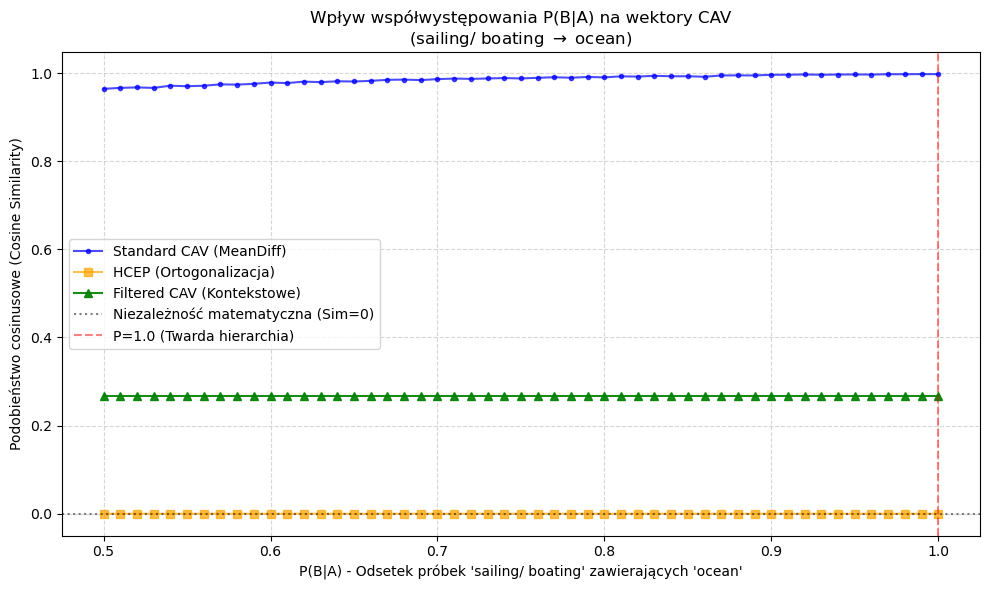

In [32]:
idx_b = np.where(y_labels[:, b_idx] == 1.0)[0]
idx_not_b = np.where(y_labels[:, b_idx] == 0.0)[0]
cav_b = calculate_centroid_cav(X_conv, idx_b, idx_not_b) 

results_md = []
results_hcep = []
results_filtered = []

print(f"Ewaluacja przejścia dla ResNet18 ({nazwa_A} -> {nazwa_B}):")
print("="*80)

for p, current_idx_a in subsets_a.items():
    idx_not_a = np.where(y_labels[:, a_idx] == 0.0)[0]

    cav_a_md = calculate_centroid_cav(X_conv, current_idx_a, idx_not_a) 
    cav_a_hcep = calculate_hcep_cav(X_conv, current_idx_a, idx_not_a, parent_cav=cav_b)
    cav_a_filtered = calculate_filtered_cav(X_conv, current_idx_a, idx_not_a, idx_b)
    
    cos_sim_filtered = get_cosine_similarity(cav_a_filtered, cav_b)
    cos_sim_md = get_cosine_similarity(cav_a_md, cav_b)
    cos_sim_hcep = get_cosine_similarity(cav_a_hcep, cav_b) 
    
    results_md.append((p, cos_sim_md))
    results_hcep.append((p, cos_sim_hcep))
    results_filtered.append((p, cos_sim_filtered))

    if round(p * 100) % 5 == 0:
        print(f"Docelowe P(B|A): {p:.2f} | MD Sim: {cos_sim_md:7.4f} | HCEP Sim: {cos_sim_hcep:7.4f} | Filtered Sim: {cos_sim_filtered:7.4f}")

probs = [res[0] for res in results_md]
sims_md = [res[1] for res in results_md]
sims_hcep = [res[1] for res in results_hcep]
sims_filtered = [res[1] for res in results_filtered]

plt.figure(figsize=(10, 6))

plt.plot(probs, sims_md, marker='.', linestyle='-', color='blue', alpha=0.7, label='Standard CAV (MeanDiff)') 
plt.plot(probs, sims_hcep, marker='s', linestyle='-', color='orange', alpha=0.7, label='HCEP (Ortogonalizacja)') 
plt.plot(probs, sims_filtered, marker='^', linestyle='-', color='green', alpha=0.9, label='Filtered CAV (Kontekstowe)')

plt.axhline(y=0.0, color='black', linestyle=':', alpha=0.5, label='Niezależność matematyczna (Sim=0)')

plt.title(f"Wpływ współwystępowania P(B|A) na wektory CAV\n({nazwa_A} $\\rightarrow$ {nazwa_B})")
plt.xlabel(f"P(B|A) - Odsetek próbek '{nazwa_A}' zawierających '{nazwa_B}'")
plt.ylabel("Podobieństwo cosinusowe (Cosine Similarity)")
plt.grid(True, linestyle='--', alpha=0.5) 

plt.axvline(x=1.0, color='red', linestyle='--', alpha=0.5, label='P=1.0 (Twarda hierarchia)')
plt.legend() 

plt.tight_layout()
plt.show()

Ewaluacja przejścia dla CLIP (sailing/ boating -> ocean):
Docelowe P(B|A): 0.50 | MD Sim:  0.9643 | HCEP Sim: -0.0000 | Filtered Sim:  0.1893
Docelowe P(B|A): 0.55 | MD Sim:  0.9705 | HCEP Sim: -0.0000 | Filtered Sim:  0.1893
Docelowe P(B|A): 0.60 | MD Sim:  0.9784 | HCEP Sim: -0.0000 | Filtered Sim:  0.1893
Docelowe P(B|A): 0.65 | MD Sim:  0.9807 | HCEP Sim: -0.0000 | Filtered Sim:  0.1893
Docelowe P(B|A): 0.70 | MD Sim:  0.9861 | HCEP Sim: -0.0000 | Filtered Sim:  0.1893
Docelowe P(B|A): 0.75 | MD Sim:  0.9876 | HCEP Sim: -0.0000 | Filtered Sim:  0.1893
Docelowe P(B|A): 0.80 | MD Sim:  0.9892 | HCEP Sim: -0.0000 | Filtered Sim:  0.1893
Docelowe P(B|A): 0.85 | MD Sim:  0.9926 | HCEP Sim: -0.0000 | Filtered Sim:  0.1893
Docelowe P(B|A): 0.90 | MD Sim:  0.9961 | HCEP Sim: -0.0000 | Filtered Sim:  0.1893
Docelowe P(B|A): 0.95 | MD Sim:  0.9959 | HCEP Sim: -0.0000 | Filtered Sim:  0.1893
Docelowe P(B|A): 1.00 | MD Sim:  0.9969 | HCEP Sim: -0.0000 | Filtered Sim:  0.1893


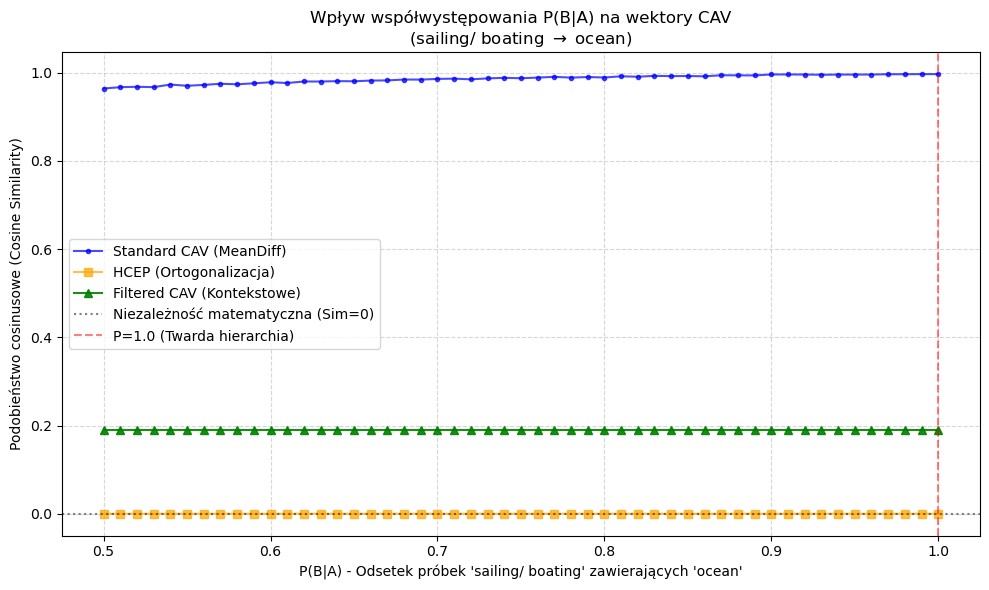

In [33]:
idx_b = np.where(y_labels[:, b_idx] == 1.0)[0]
idx_not_b = np.where(y_labels[:, b_idx] == 0.0)[0]
cav_b = calculate_centroid_cav(X_clip, idx_b, idx_not_b)

results_md = []
results_hcep = []
results_filtered = []

print(f"Ewaluacja przejścia dla CLIP ({nazwa_A} -> {nazwa_B}):")
print("="*80)

for p, current_idx_a in subsets_a.items():
    idx_not_a = np.where(y_labels[:, a_idx] == 0.0)[0]

    cav_a_md = calculate_centroid_cav(X_clip, current_idx_a, idx_not_a) 
    cav_a_hcep = calculate_hcep_cav(X_clip, current_idx_a, idx_not_a, parent_cav=cav_b)
    cav_a_filtered = calculate_filtered_cav(X_clip, current_idx_a, idx_not_a, idx_b)
    
    
    cos_sim_md = get_cosine_similarity(cav_a_md, cav_b)
    cos_sim_hcep = get_cosine_similarity(cav_a_hcep, cav_b) 
    cos_sim_filtered = get_cosine_similarity(cav_a_filtered, cav_b)
    
    results_md.append((p, cos_sim_md))
    results_hcep.append((p, cos_sim_hcep))
    results_filtered.append((p, cos_sim_filtered))

    if round(p * 100) % 5 == 0:
        print(f"Docelowe P(B|A): {p:.2f} | MD Sim: {cos_sim_md:7.4f} | HCEP Sim: {cos_sim_hcep:7.4f} | Filtered Sim: {cos_sim_filtered:7.4f}")

probs = [res[0] for res in results_md]
sims_md = [res[1] for res in results_md]
sims_hcep = [res[1] for res in results_hcep]
sims_filtered = [res[1] for res in results_filtered]

plt.figure(figsize=(10, 6))

plt.plot(probs, sims_md, marker='.', linestyle='-', color='blue', alpha=0.7, label='Standard CAV (MeanDiff)') 
plt.plot(probs, sims_hcep, marker='s', linestyle='-', color='orange', alpha=0.7, label='HCEP (Ortogonalizacja)') 
plt.plot(probs, sims_filtered, marker='^', linestyle='-', color='green', alpha=0.9, label='Filtered CAV (Kontekstowe)')

plt.axhline(y=0.0, color='black', linestyle=':', alpha=0.5, label='Niezależność matematyczna (Sim=0)')

plt.title(f"Wpływ współwystępowania P(B|A) na wektory CAV\n({nazwa_A} $\\rightarrow$ {nazwa_B})")
plt.xlabel(f"P(B|A) - Odsetek próbek '{nazwa_A}' zawierających '{nazwa_B}'")
plt.ylabel("Podobieństwo cosinusowe (Cosine Similarity)")
plt.grid(True, linestyle='--', alpha=0.5) 

plt.axvline(x=1.0, color='red', linestyle='--', alpha=0.5, label='P=1.0 (Twarda hierarchia)')
plt.legend() 

plt.tight_layout()
plt.show()

##### Brak różnicy między modelami. Model interpretuje koncepty jako bliższe sobie jeśli P(B|A) jest wyższe. Jeśli więcej zniekształconych danych (współwystępujących) tym bardziej MeanDiff postrzega pojęcia jako to samo. HCEP jest na to odporny i ortogonalizuje.

### Analiza usuwania wpływu rodzica

In [36]:
def evaluate_siblings_orthogonality(df, features, child1, child2, parent):
    idx_c1_pos = df.index[df[child1] == 1.0].tolist()
    idx_c1_neg = df.index[df[child1] == 0.0].tolist()
    
    idx_c2_pos = df.index[df[child2] == 1.0].tolist()
    idx_c2_neg = df.index[df[child2] == 0.0].tolist()
    
    idx_p_pos = df.index[df[parent] == 1.0].tolist()
    idx_p_neg = df.index[df[parent] == 0.0].tolist()

    cav_p = calculate_centroid_cav(features, idx_p_pos, idx_p_neg)
    cav_c1_md = calculate_centroid_cav(features, idx_c1_pos, idx_c1_neg)
    cav_c2_md = calculate_centroid_cav(features, idx_c2_pos, idx_c2_neg)

    cav_c1_hcep = calculate_hcep_cav(features, idx_c1_pos, idx_c1_neg, parent_cav=cav_p)
    cav_c2_hcep = calculate_hcep_cav(features, idx_c2_pos, idx_c2_neg, parent_cav=cav_p)
    
    cav_c1_filtered = calculate_filtered_cav(features, idx_c1_pos, idx_c1_neg, idx_p_pos)
    cav_c2_filtered = calculate_filtered_cav(features, idx_c2_pos, idx_c2_neg, idx_p_pos)

    sim_md = get_cosine_similarity(cav_c1_md, cav_c2_md)
    sim_hcep = get_cosine_similarity(cav_c1_hcep, cav_c2_hcep)
    sim_filtered = get_cosine_similarity(cav_c1_filtered, cav_c2_filtered)

    return {
        'Rodzeństwo': f"{child1} vs {child2}",
        'Rodzic': parent,
        'CosSim MeanDiff': round(sim_md, 4),
        'CosSim HCEP': round(sim_hcep, 4),
        'CosSim Filtered': round(sim_filtered, 4),
        
        'Różnica HCEP - MeanDiff': round(sim_hcep - sim_md, 4),
        'Różnica Filtered - MeanDiff': round(sim_filtered - sim_md, 4)
    }

In [37]:
sibling_result = evaluate_siblings_orthogonality(df_sun, X_conv, 'gaming', 'research', 'enclosed area')
print(sibling_result)

{'Rodzeństwo': 'gaming vs research', 'Rodzic': 'enclosed area', 'CosSim MeanDiff': 0.4303, 'CosSim HCEP': -0.0393, 'CosSim Filtered': -0.0199, 'Różnica HCEP - MeanDiff': -0.4696, 'Różnica Filtered - MeanDiff': -0.4501}


In [38]:
sibling_result = evaluate_siblings_orthogonality(df_sun, X_conv, 'medical activity', 'research', 'enclosed area')
print(sibling_result)

{'Rodzeństwo': 'medical activity vs research', 'Rodzic': 'enclosed area', 'CosSim MeanDiff': 0.8398, 'CosSim HCEP': 0.7253, 'CosSim Filtered': 0.747, 'Różnica HCEP - MeanDiff': -0.1145, 'Różnica Filtered - MeanDiff': -0.0929}


### W którym momencie wymuszanie hierarchii pogarsza jakość wektora?

In [39]:
def get_directional_sensitivity(target_weight, cav):
    """
    Oblicza wpływ wektora CAV na klasę docelową (TCAV Score w przestrzeni liniowej).
    Wartość > 0 oznacza, że pojęcie sprzyja predykcji tej klasy.
    Wartość < 0 oznacza, że pojęcie osłabia predykcję tej klasy.
    """
    return np.dot(target_weight, cav)

def generate_random_cavs(features, num_runs=100, sample_size=300):
    """
    Generuje wektory CAV z losowych wycinków tła, aby zasymulować szum statystyczny.
    """
    random_cavs = []
    n_samples = features.shape[0]
    
    for _ in range(num_runs):
        idx_pos = np.random.choice(n_samples, sample_size, replace=False)
        idx_neg = np.random.choice(n_samples, sample_size, replace=False)
        rand_cav = calculate_centroid_cav(features, idx_pos, idx_neg)
        random_cavs.append(rand_cav)
        
    return random_cavs

def calculate_empirical_p_value(true_score, random_scores):
    """
    Zwraca p-value określające, czy prawdziwy wynik jest lepszy od szumu.
    p-value < 0.05 oznacza istotność statystyczną.
    """
    random_scores = np.array(random_scores)
    p_val = np.sum(random_scores >= true_score) / len(random_scores)
    return p_val

In [41]:
specific_setup = {
    "beach": [
        ('ocean', 'open area'), 
        ('sand', 'natural light')
    ],
    "office": [
        ('conducting business', 'working'), 
        ('carpet', 'enclosed area'), 
        ('research', 'enclosed area')
    ],
    "snowy mountain": [
        ('ice', 'cold'), 
        ('climbing', 'rock/stone')
    ]
}

print("Generowanie 100 losowych wektorów CAV (szum statystyczny)...")
random_cavs = generate_random_cavs(X_clip, num_runs=100, sample_size=300)

tcav_results = []

for target_scene, pairs_to_test in specific_setup.items():
    print(f"Analiza dla sceny docelowej: '{target_scene}'...")

    target_weight = get_text_cav_clip(target_scene)

    random_tcav_scores = [get_directional_sensitivity(target_weight, r_cav) for r_cav in random_cavs]
    
    for child, parent in pairs_to_test:
        idx_c_pos = df_sun.index[df_sun[child] == 1.0].tolist()
        idx_c_neg = df_sun.index[df_sun[child] == 0.0].tolist()
        idx_p_pos = df_sun.index[df_sun[parent] == 1.0].tolist()
        idx_p_neg = df_sun.index[df_sun[parent] == 0.0].tolist()
        
        if len(idx_c_pos) < 10: 
            continue

        cav_parent = calculate_centroid_cav(X_clip, idx_p_pos, idx_p_neg)
        cav_child_md = calculate_centroid_cav(X_clip, idx_c_pos, idx_c_neg)
        cav_child_hcep = calculate_hcep_cav(X_clip, idx_c_pos, idx_c_neg, parent_cav=cav_parent)
        cav_child_filtered = calculate_filtered_cav(X_clip, idx_c_pos, idx_c_neg, idx_p_pos)
        
        tcav_md = get_directional_sensitivity(target_weight, cav_child_md)
        tcav_hcep = get_directional_sensitivity(target_weight, cav_child_hcep)
        tcav_filtered = get_directional_sensitivity(target_weight, cav_child_filtered)

        pval_md = calculate_empirical_p_value(tcav_md, random_tcav_scores)
        pval_hcep = calculate_empirical_p_value(tcav_hcep, random_tcav_scores)
        pval_filtered = calculate_empirical_p_value(tcav_filtered, random_tcav_scores)

        tcav_results.append({
            'Scena Docelowa': target_scene,
            'Pojęcie (Dziecko)': child,
            'Tło (Rodzic)': parent,
            
            'TCAV MD': round(tcav_md, 4),
            'P-Val MD': pval_md,
            'Znaczący MD?': 'Tak' if pval_md < 0.05 else 'Nie',
            
            'TCAV HCEP': round(tcav_hcep, 4),
            'P-Val HCEP': pval_hcep,
            'Znaczący HCEP?': 'Tak' if pval_hcep < 0.05 else 'Nie',

            'TCAV Filtered': round(tcav_filtered, 4),
            'P-Val Filtered': pval_filtered,
            'Znaczący Filtered?': 'Tak' if pval_filtered < 0.05 else 'Nie'
        
        })

df_specific_tcav = pd.DataFrame(tcav_results)

display(df_specific_tcav)

Generowanie 100 losowych wektorów CAV (szum statystyczny)...
Analiza dla sceny docelowej: 'beach'...
Analiza dla sceny docelowej: 'office'...
Analiza dla sceny docelowej: 'snowy mountain'...


,Scena Docelowa,Pojęcie (Dziecko),Tło (Rodzic),TCAV MD,P-Val MD,Znaczący MD?,TCAV HCEP,P-Val HCEP,Znaczący HCEP?,TCAV Filtered,P-Val Filtered,Znaczący Filtered?
0,beach,ocean,open area,0.2398,0.00,Tak,0.2201,0.00,Tak,0.2388,0.00,Tak
1,beach,sand,natural light,0.1757,0.00,Tak,0.1425,0.01,Tak,0.1617,0.00,Tak
2,office,conducting business,working,0.2284,0.00,Tak,0.1159,0.04,Tak,0.2116,0.00,Tak
3,office,carpet,enclosed area,0.1864,0.01,Tak,0.0808,0.10,Nie,0.1196,0.03,Tak
4,office,research,enclosed area,0.2320,0.00,Tak,0.1593,0.01,Tak,0.1847,0.01,Tak
5,snowy mountain,ice,cold,0.2308,0.00,Tak,-0.0705,0.94,Nie,0.0796,0.05,Nie
6,snowy mountain,climbing,rock/stone,0.1473,0.00,Tak,0.1831,0.00,Tak,0.1223,0.00,Tak


#### TCAV mówi czy pojęcie podrzędne ma wpływ na wykrywanie nadrzędnego typu beach. Czy dodanie informacji o tym czy jest piasek popycha model do wykrywania plaży. TCAV MD oznacza jak dziecko z rodzicem wpływa na zwiększenie prawdopobieństwa wykrycia plaży, a TCAV HCEP jak tylko pojęcie dziecka wpływa na wykrywanie sceny docelowej. 